# Question 3: SMB Bundle Dashboard

## Assignment

<!-- Original Q3 assignment prompt from `Business Case for BA 2026 - SMB Bundles.pdf`. Do not edit unless specifically requested. -->

> **Question 3: How do we monitor the sales?**
>
> Flashforward to after the launch of the SMB Bundles. Thanks to your outreach prioritization we have done several subsequent batches of calls, and bundle registrations have been coming in. In the third dataset you can find an overview of SMB sellers from both SYI and Pro, showing which bundle they purchased, with a start and end date.
>
> As a promotion, the first 28 days are for free. After that they pay:
>
> - €19.99 per 4 weeks for a Basic bundle
> - €49.99 per 4 weeks for a Plus bundle
>
> Every seller can only get a discount once. They can stop their bundle, or switch to another one at any point in the month. For this business case, assume they immediately pay for the full 4 weeks (unless it’s their first bundle ever and thus get a discount), and do not get a refund for any time left in their previous bundle.
>
> Design and present a dashboard that will help you show the impact of our Bundle introduction, and any other important analysis or metrics. The dashboard should both be useful at the launch and at the later stages. Use the data that is available to already fill parts of your dashboard design, while clearly stating what other data you would need to complete your view.

## 0. Data Structure

In [1]:
import importlib

from IPython.display import Markdown, display

import functions

functions = importlib.reload(functions)
pd = functions.pd
plt = functions.plt

functions.set_plot_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.1f}".format)


In [2]:
dashboard = functions.q3_dashboard_data()

bundle_df = dashboard["bundle_df"]
launch_start = dashboard["launch_start"]
dashboard_reference_date = dashboard["dashboard_reference_date"]
seller_fields = dashboard["seller_fields"]
weekly_metrics = dashboard["weekly_metrics"]
revenue_4w = dashboard["revenue_4w"]
revenue_by_bundle = dashboard["revenue_by_bundle"]
registrations_4w = dashboard["registrations_4w"]
cohort_metrics_28d = dashboard["cohort_metrics_28d"]
segment_metrics = dashboard["segment_metrics"]


In [3]:
print(f"Dashboard reference date: {dashboard_reference_date:%Y-%m-%d}")
print(f"Launch start date: {launch_start:%Y-%m-%d}")

display(functions.q3_structure_summary(bundle_df, dashboard_reference_date))
display(functions.q3_distribution_summary(bundle_df))


Dashboard reference date: 2025-04-29
Launch start date: 2024-02-29


,Metric,Value
0,Rows,"8,830"
1,Unique sellers,"4,076"
2,Start date range,2024-02-29 to 2025-04-29
3,Finite end date range,2024-03-04 to 2025-04-29
4,Open-ended rows,"4,094"
5,Missing values,0
6,Duplicate rows,0
7,Sellers with potential overlapping intervals,18


,Field,Value,Rows
0,Customer type,SYI,6802
1,Customer type,Pro,2028
2,Bundle,Basic,3777
3,Bundle,No bundle,2728
4,Bundle,Plus,2325


### 0.1 EDA Snapshot

- **Purpose:** identify dataset facts that affect dashboard interpretation.
- **Scope:** focused EDA only; not a full exploration.

In [4]:
display(
    functions.q3_short_eda_summary(
        bundle_df,
        seller_fields,
        weekly_metrics,
        revenue_4w,
        dashboard_reference_date,
    )
)


,Metric,Value
0,First bundle starters,"4,076"
1,Basic-first share,68.5%
2,Plus-first share,31.5%
3,Peak weekly registrations,432 in week of 2024-04-01
4,Latest active paid bundles,"2,709"
5,Latest active trial bundles,0
6,Current no-bundle sellers,"1,367"
7,Current Plus share of paid base,40.9%
8,Sellers with multiple bundle periods,"1,545"
9,Sellers using both Basic and Plus,"1,042"


### 0.2 Customer Type Deep Dive

- **Finding:** customer type changes segment size more than bundle quality.
- **Evidence:** Pro is smaller and starts slightly more often on Plus. Paid Plus share and no-bundle share are close to SYI.
- **Use:** keep customer type as a filter, not the main steering signal.

In [5]:
display(functions.q3_customer_type_eda_display_table(bundle_df, seller_fields))

,Customer type,Bundle starters,Basic-first share,Plus-first share,Active paid bundles,Plus share of active paid bundles,Current no-bundle share,Multiple bundle-period share,Used Basic and Plus share
0,SYI,"3,137",69.2%,30.8%,"2,093",40.9%,33.3%,38.1%,26.1%
1,Pro,939,66.1%,33.9%,616,40.7%,34.4%,37.3%,23.7%


In [6]:
display(Markdown(functions.q3_customer_type_insights_markdown(bundle_df, seller_fields)))

- **Pro sellers are a smaller part of the file**  
  Evidence: Pro: 939 starters; SYI: 3,137 starters.  
  Interpretation: Customer type matters for sizing, but not necessarily for quality.
- **Pro starts slightly more often on Plus**  
  Evidence: Plus-first share: Pro 33.9%; SYI 30.8%.  
  Interpretation: This is directionally useful for positioning, but the gap is modest.
- **Paid mix is nearly the same**  
  Evidence: Paid Plus share: Pro 40.7%; SYI 40.9%.  
  Interpretation: Customer type alone does not strongly separate monetization quality.
- **No-bundle share is also similar**  
  Evidence: No-bundle share: Pro 34.4%; SYI 33.3%.  
  Interpretation: Customer type is not a strong churn/status signal in this dataset.

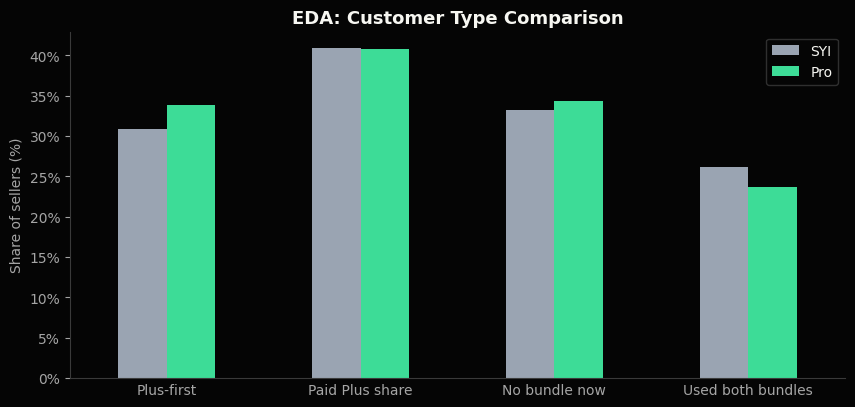

In [7]:
functions.plot_q3_customer_type_comparison(bundle_df, seller_fields)
plt.show()

### 0.3 Launch Demand Was Front-Loaded

- **Finding:** registrations peaked soon after launch, then moved to a lower run-rate.
- **Evidence:** weekly first-bundle registrations with the peak week highlighted.
- **Use:** after launch, focus less on raw starts and more on paid base and retention.

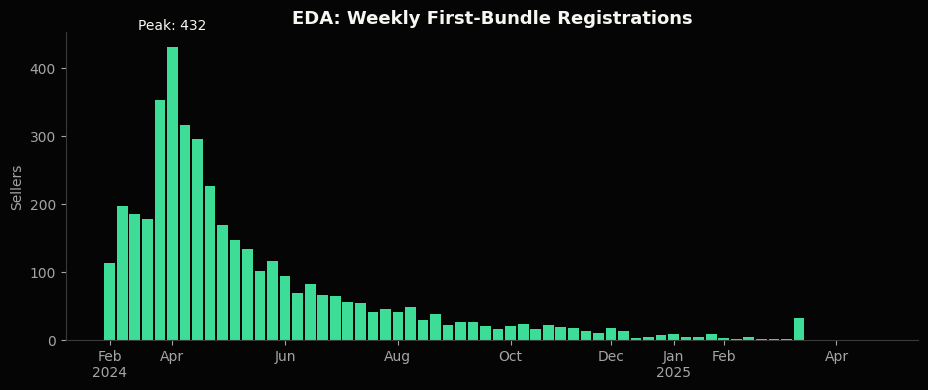

In [8]:
functions.plot_q3_eda_launch_demand(weekly_metrics)
plt.show()


### 0.4 Basic Drives Entry, Plus Drives Monetization

- **Finding:** most sellers start on Basic.
- **Evidence:** Plus is a larger share of the current paid base than of first starts.
- **Use:** track Basic for adoption and Plus share for monetization quality.

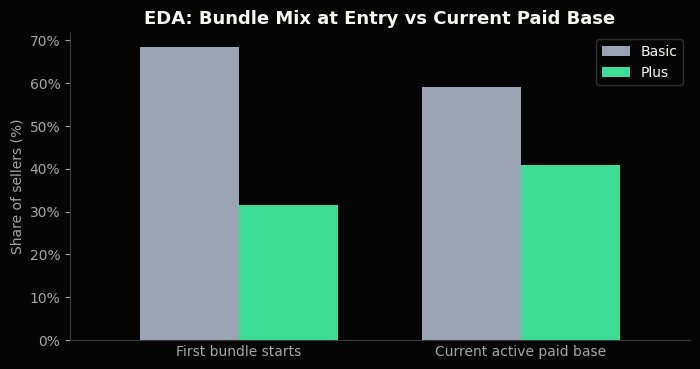

In [9]:
functions.plot_q3_eda_bundle_mix_shift(seller_fields)
plt.show()


### 0.5 Current Status Includes No Bundle

- **Finding:** many bundle starters now have a current `No bundle` interval.
- **Meaning:** `No bundle` means the seller is currently not on Basic or Plus.
- **Use:** include no-bundle status when reading churn and current base size.

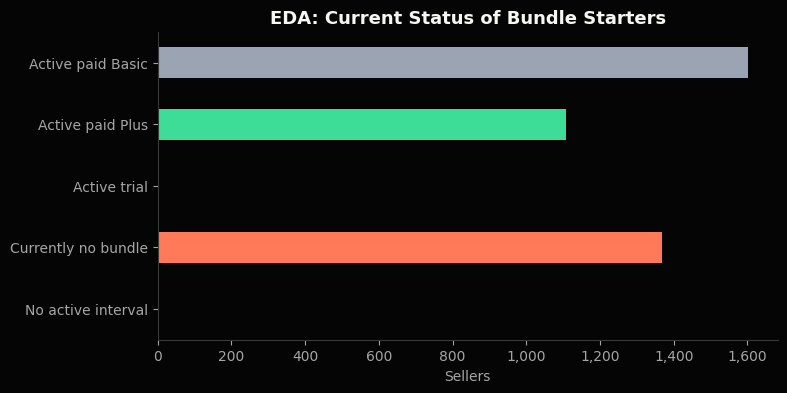

In [10]:
functions.plot_q3_eda_current_status(seller_fields)
plt.show()


### 0.6 Bundle Status Over Time

- **Finding:** sellers shift from no bundle into Basic and Plus after launch.
- **Evidence:** weekly status of all unique sellers in this file.
- **Use:** shows paid bundle base and remaining no-bundle pool together.

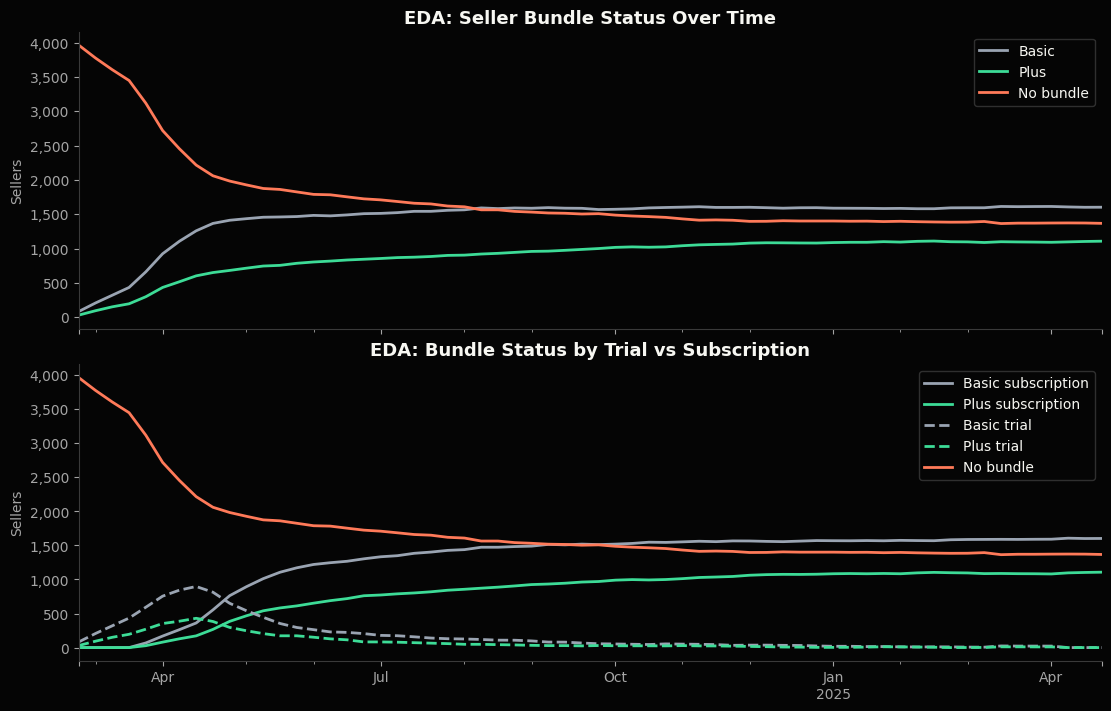

In [11]:
functions.plot_q3_eda_bundle_status_timeseries(
    bundle_df,
    seller_fields,
    launch_start,
    dashboard_reference_date,
)
plt.show()


### 0.7 Open-Ended Means Still Active

- **Finding:** many rows end on `2099-12-31`.
- **Meaning:** this is a placeholder for a currently active interval.
- **Use:** treat these rows as active, not as real future end dates.

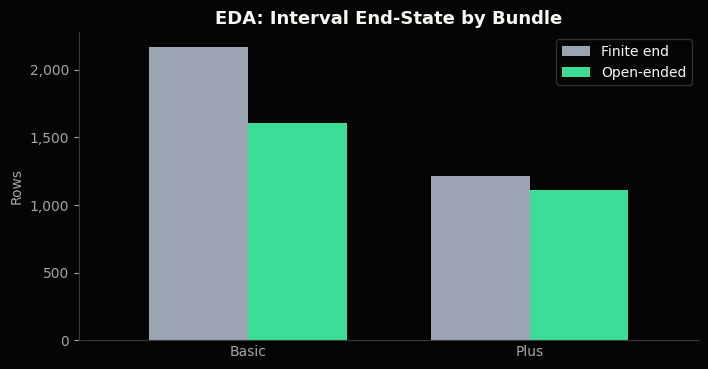

In [12]:
functions.plot_q3_eda_open_ended_intervals(bundle_df)
plt.show()


### 0.8 Repeat Bundle Periods and Switching Are Common

- **Finding:** many sellers have multiple bundle periods; some used both Basic and Plus.
- **Meaning:** repeated rows can be renewals, stops, or switches.
- **Use:** calculate dashboard metrics at seller and period level.

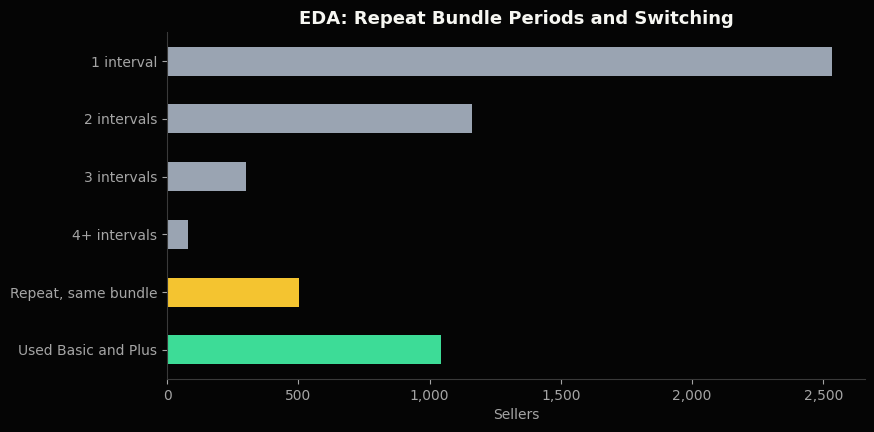

In [13]:
functions.plot_q3_eda_interval_complexity(bundle_df)
plt.show()


## 1. Sales Overview

- **Question:** are SMB Bundles gaining commercial traction?
- **View:** demand, active bundles, Plus mix, and modeled paid revenue.
- **Controls:** date range, customer type, bundle. Break down time-series by bundle or customer type.
- **Read first:** KPI snapshot, then active bundles and modeled revenue.
- **Limit:** revenue is modeled from intervals and list prices, not invoices.

### 1.1 KPI Snapshot

- **Purpose:** latest headline readout for the dashboard.
- **New registration in 4wk:** rolling 4-week window.
- **Modeled revenue:** latest complete 4-week period.

In [14]:
display(
    functions.q3_sales_kpis(
        weekly_metrics,
        revenue_4w,
        dashboard_reference_date,
        registrations_4w,
        seller_fields,
    )
)


,Reference date,Active paid bundles,Active trial bundles,New registration in 4wk,Plus share of active paid bundles,Modeled revenue in latest complete 4wk period
0,2025-04-29,"2,709 (+0% w/w)",0 (+0% w/w),41 (+156% vs prior 4wk),40.9% (+0.1pp w/w),"€88,373 (+0% vs prev 4wk)"


### 1.2 Weekly New Registrations

- **Question:** is launch demand growing, stable, or fading?
- **Measure:** sellers whose first Basic or Plus bundle starts each week.
- **Important:** registrations include free-trial starts, not paid subscriptions.
- **Chart:** total registrations, plus Basic vs Plus.
- **Controls:** date range, customer type, bundle. Break down by bundle or customer type.
- **Limit:** registrations do not prove paid adoption.

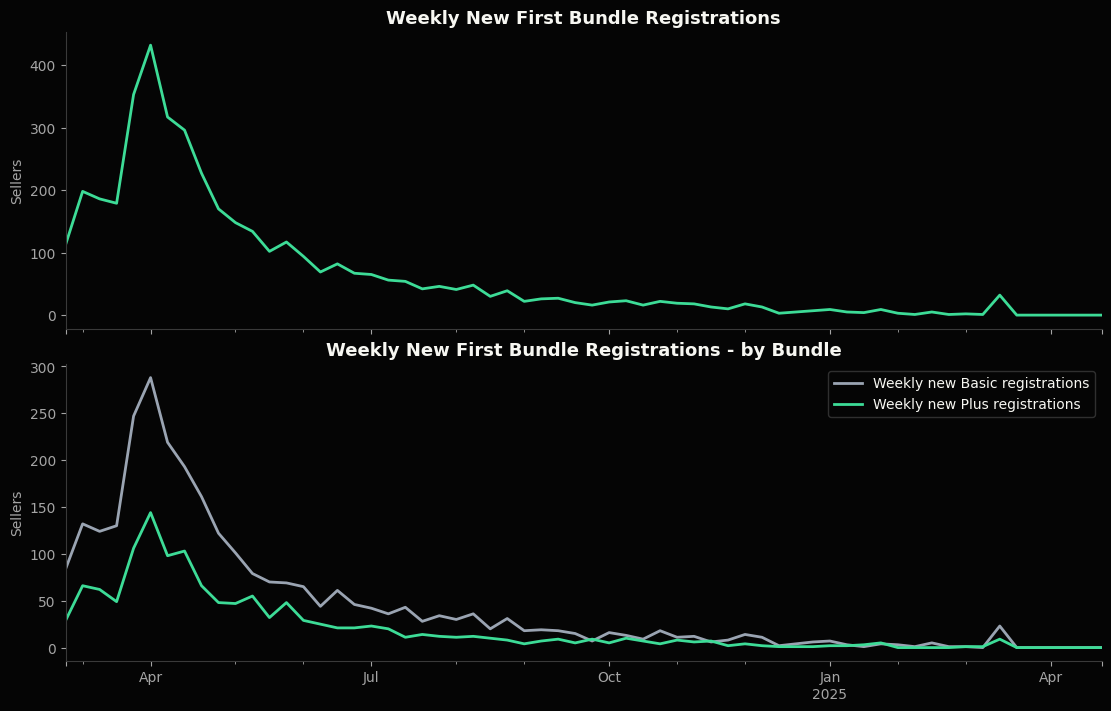

In [15]:
functions.plot_q3_weekly_new_registrations(weekly_metrics)
plt.show()


### 1.3 Active Bundles

- **Question:** is the bundle base turning into paid adoption?
- **Measure:** active trial bundles and active paid bundles.
- **Chart:** total trial vs paid, then Basic vs Plus. Solid lines are paid; dashed lines are trial.
- **Controls:** date range, customer type, bundle. Break down by bundle, paid/trial status, or customer type.
- **Limit:** active status comes from registration intervals, not payment collection records.

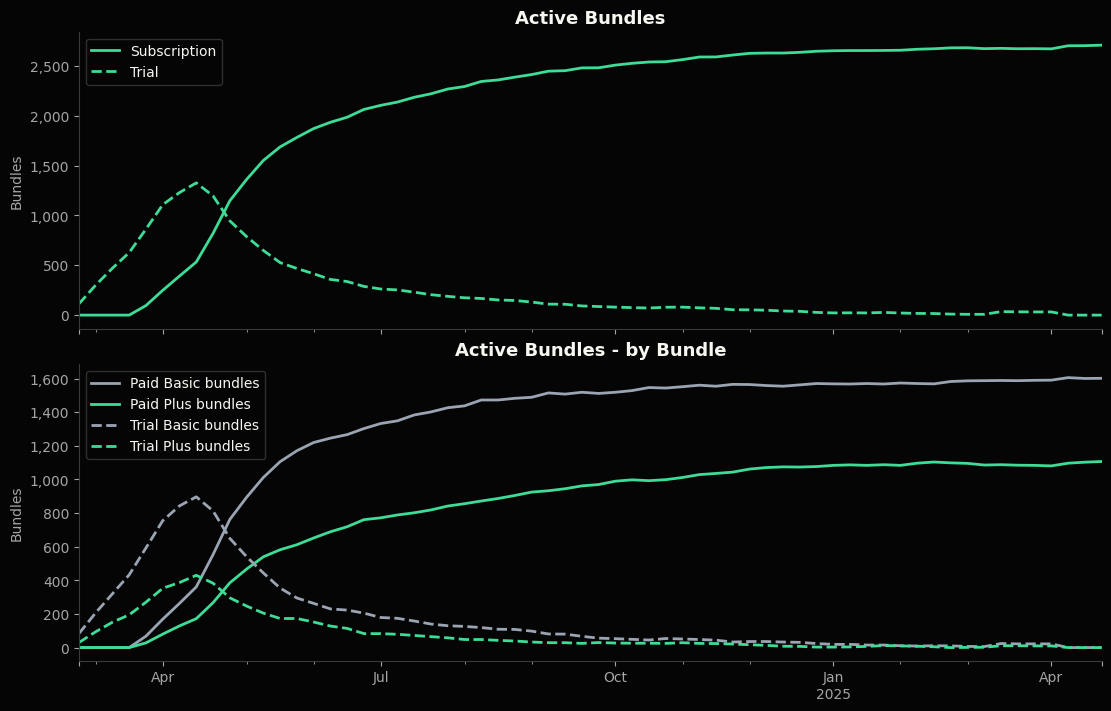

In [16]:
functions.plot_q3_active_bundle_sellers(weekly_metrics)
plt.show()

### 1.4 Plus Share

- **Question:** is the paid base shifting toward Plus?
- **Measure:** active paid Plus bundles / all active paid bundles.
- **Chart:** Plus share over time.
- **Controls:** date range and customer type. Break down by customer type.
- **Use:** monetization quality, not adoption volume.
- **Limit:** does not explain why sellers choose Plus.

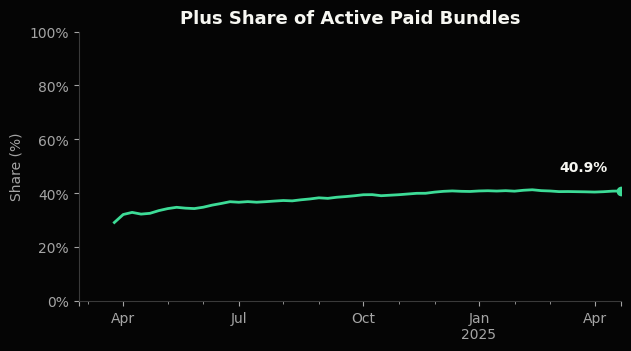

In [17]:
functions.plot_q3_plus_share(weekly_metrics)
plt.show()


## 2. Customer Quality

- **Question:** are registrations becoming retained paid customers?
- **View:** cohort health and segment snapshot.
- **Read first:** cohort rows show when sellers started; maturity columns show how long they have had to convert and stay paid.
- **Limit:** early subscription quality only; not LTV or seller outcomes.

### 2.1 Cohort Health

- **Question:** do cohorts stay active paid after trial and later billing cycles?
- **Rows:** sellers grouped by 28-day first-bundle start window.
- **Columns:** active paid rate at 4wk, 8wk, 12wk, 16wk, 20wk, and 24wk.
- **Important:** blank cells are immature checkpoints, not zero conversion.
- **Chart:** darker cells mean stronger active paid rates.
- **Limit:** cohort differences can reflect mix, targeting, or small sample sizes.

In [18]:
display(functions.q3_cohort_heatmap_table(cohort_metrics_28d))

### 2.2 Segmentation Analysis

- **Question:** which segments look stronger now?
- **Current metrics:** registrations, 4wk paid conversion, Plus share, active paid bundles, no-bundle share.
- **Current cuts:** customer type, first bundle type, current bundle status.
- **How to use:** snapshot comparison only. Use Sales Overview filters for time-series movement.
- **Potential merges:** high-value ideas only; not joined in the current Q3 file.

In [19]:
display(functions.q3_segment_display_table(segment_metrics))

display(Markdown(functions.q3_markdown_table(functions.q3_segment_enrichment_opportunities())))

,Segment,Segment value,Registrations,Day-28 paid conversion,Plus share of active paid bundles,Active paid bundles,Current no-bundle share
0,Current bundle status,Basic,"1,602",93.4%,0.0%,"1,602",0.0%
1,Current bundle status,No bundle,"1,367",83.3%,,0,100.0%
2,Current bundle status,Plus,"1,107",90.2%,100.0%,"1,107",0.0%
3,Customer type,SYI,"3,137",89.1%,40.9%,"2,093",33.3%
4,Customer type,Pro,939,89.5%,40.7%,616,34.4%
5,First bundle type,Basic-first,"2,791",89.4%,25.5%,"1,845",33.9%
6,First bundle type,Plus-first,"1,285",88.7%,73.6%,864,32.8%


| Potential merge | Why it helps |
| --- | --- |
| SMB likelihood score | Separates likely business sellers from lighter consumer-like sellers. |
| Outreach readiness score | Shows whether sales-prioritized sellers convert and retain better. |
| Historical spend tier | Distinguishes high-value sellers from low-spend adopters. |
| Seller size / activity tier | Identifies whether bundles work better for large or small sellers. |
| Pro performance tier | Separates Pro sellers with real traffic from Pro sellers with low engagement. |
| Seller outcome tier | Shows whether bundles create value for sellers, not only platform revenue. |
| Outreach batch / channel | Connects launch execution to registration and paid conversion quality. |

#### Segmentation Mockup

- **Purpose:** show how merged segment data could flag sharp changes.
- **Use:** identify segments needing action now.
- **Important:** dummy data only; not current measured results.

In [20]:
display(Markdown(functions.q3_markdown_table(functions.q3_segment_mockup_descriptions())))

| Mock visualization | Potential merged data | What it would show |
| --- | --- | --- |
| Recent change alerts | Daily or weekly segment snapshots joined to registration history | Sharp 4-week changes in active paid bundles, no-bundle share, or Plus share. |

##### Recent Segment Change Alerts

- **What is shown:** largest recent changes in active paid rate by segment.
- **Why it matters:** highlights where follow-up is most urgent.

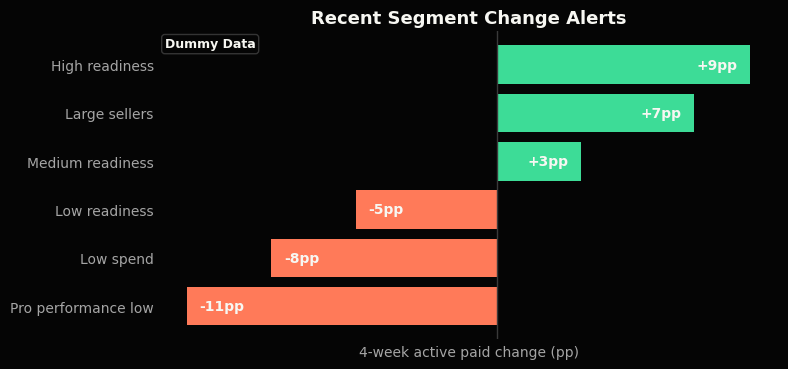

In [21]:
functions.plot_q3_mock_smb_fit_seller_size()
plt.show()

## 3. Business Impact

- **Question:** are bundles creating measurable value for Marktplaats and sellers?
- **View:** modeled paid revenue from current data, plus a seller-outcome mockup for the missing value view.
- **Current data supports:** modeled paid revenue and bundle revenue mix.
- **Still missing:** actual revenue offsets and seller outcome data.
- **Limit:** cannot prove incrementality or seller value uplift from registrations alone.

### 3.1 Modeled Paid Revenue

- **Question:** is monetized adoption translating into subscription revenue?
- **Measure:** modeled paid revenue from bundle intervals, list prices, trial timing, and no-refund switching.
- **Billing rule:** sellers do not generate paid revenue before their 28-day trial ends.
- **Charts:** 4-week modeled revenue trend and latest complete 4-week Basic vs Plus split.
- **Limit:** modeled paid revenue, not invoiced revenue or net incremental revenue.

,period_start,modeled_paid_revenue_eur,paid_billing_events
8,2024-10-10,"€84,993","2,670"
9,2024-11-07,"€87,303","2,727"
10,2024-12-05,"€87,573","2,721"
11,2025-01-02,"€88,243","2,738"
12,2025-01-30,"€88,723","2,744"
13,2025-02-27,"€88,123","2,735"
14,2025-03-27,"€88,373","2,746"
15,2025-04-24,"€21,144",648


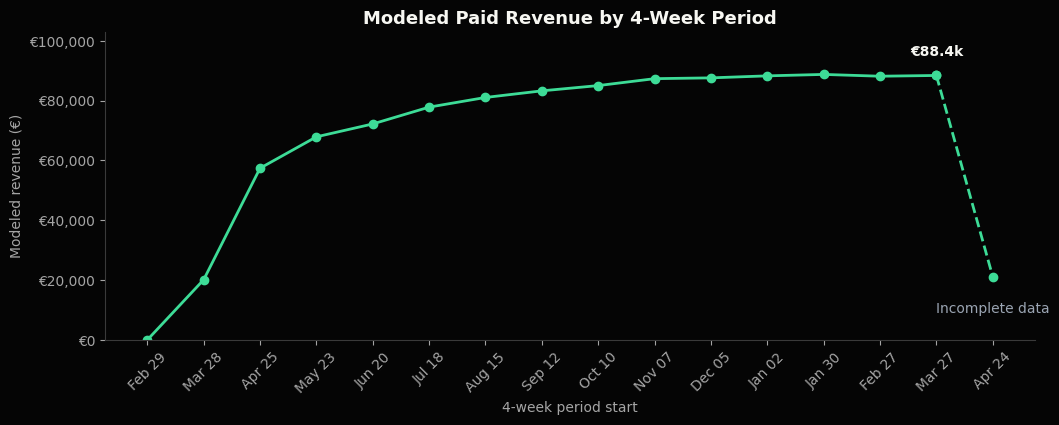

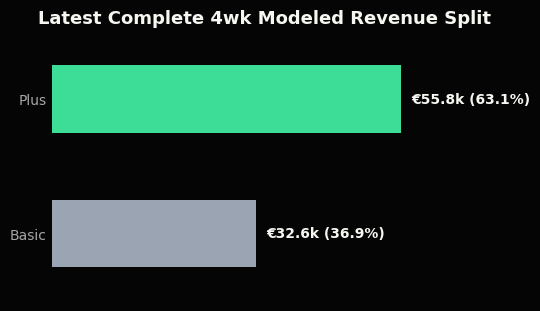

In [22]:
display(functions.q3_revenue_display_table(revenue_4w))

functions.plot_q3_modeled_revenue(revenue_4w, dashboard_reference_date)
plt.show()

functions.plot_q3_latest_revenue_by_bundle(revenue_by_bundle, dashboard_reference_date)
plt.show()

### 3.2 Seller Outcome Uplift Mockup

- **Question:** do bundles help sellers generate more leads?
- **Measure:** lead uplift vs each bundle segment's pre-bundle baseline.
- **Chart:** dummy uplift over weeks from bundle start; Basic grey, Plus green.
- **Why it matters:** shows the seller-value view missing from the current file.
- **Required data:** seller-level leads by date joined to bundle start date.
- **Limit:** dummy data only; registrations do not include lead outcomes.

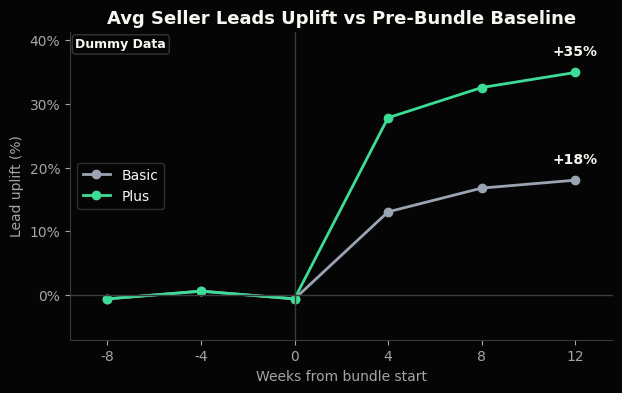

In [23]:
functions.plot_q3_mock_seller_leads_uplift()
plt.show()
